**Programmer: python_scripts (Abhijith Warrier)**

**🔐 PYTHON SCRIPT TO DEMO: _HOW DATA POISONING AFFECTS ML MODEL ACCURACY_**

Explore how corrupted training data can influence a machine learning model's accuracy and predictions.
This lab simulates a controlled data poisoning attack, measures its impact, and demonstrates how data validation can help identify suspicious training samples.

---

## 🎯 Lab Objective

Data poisoning occurs when malicious or corrupted information is introduced into the data used to train a machine learning model.

Unlike adversarial examples, which manipulate inputs during inference, data poisoning targets the learning process itself.

In this lab, we'll:

- Train a classification model using clean training data.
- Simulate a label-flipping attack by corrupting selected training labels.
- Compare model accuracy and predictions before and after poisoning.
- Identify suspicious training records using a trusted reference dataset.
- Retrain the model after removing corrupted labels and verify the results.

Our goal is to understand how training data integrity affects ML model reliability.

---

## 🟢 Build the Baseline

We'll use Scikit-learn's synthetic classification dataset to create a controlled machine learning experiment.

The dataset will contain two classes with multiple numerical features.

First, we'll split the dataset into training and testing sets, standardise the features, and train a Logistic Regression classifier.

The test dataset will remain clean throughout the experiment so we can measure how poisoning affects model performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    flip_y=0,
    class_sep=1.5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"Baseline Accuracy: {baseline_accuracy:.2%}")

Training Samples: 1500
Testing Samples: 500
Baseline Accuracy: 93.20%


---

## 🔴 Simulate the Attack

We'll now simulate a label-flipping data poisoning attack.

Label flipping occurs when the class labels associated with training samples are deliberately changed.

For example, a sample originally labelled as Class 0 may be incorrectly labelled as Class 1.

We'll corrupt 30% of the training labels while leaving the input features unchanged.

The poisoned dataset will then be used to train a second model.

In [2]:
rng = np.random.default_rng(42)

poison_rate = 0.30
poisoned_labels = y_train.copy()

poison_count = int(len(poisoned_labels) * poison_rate)
poison_indices = rng.choice(len(poisoned_labels), size=poison_count, replace=False)

poisoned_labels[poison_indices] = 1 - poisoned_labels[poison_indices]

poisoned_model = LogisticRegression(max_iter=1000, random_state=42)
poisoned_model.fit(X_train_scaled, poisoned_labels)

poisoned_predictions = poisoned_model.predict(X_test_scaled)
poisoned_accuracy = accuracy_score(y_test, poisoned_predictions)

print(f"Poisoning Rate: {poison_rate:.0%}")
print(f"Corrupted Labels: {poison_count}")
print(f"Baseline Accuracy: {baseline_accuracy:.2%}")
print(f"Poisoned Accuracy: {poisoned_accuracy:.2%}")

Poisoning Rate: 30%
Corrupted Labels: 450
Baseline Accuracy: 93.20%
Poisoned Accuracy: 90.00%


---

## 🔍 Observe the Impact

Now we'll compare the clean and poisoned models.

We'll examine:

- Overall classification accuracy.
- The number of predictions that changed.
- Accuracy differences between the models.
- Confusion matrices showing classification errors.

This helps us understand how corrupted training labels influence model behaviour.

In [3]:
accuracy_drop = baseline_accuracy - poisoned_accuracy
changed_predictions = np.sum(baseline_predictions != poisoned_predictions)

comparison = pd.DataFrame({
    "Model": ["Baseline Model", "Poisoned Model"],
    "Accuracy": [baseline_accuracy, poisoned_accuracy],
    "Training Data": ["Clean", "30% Labels Corrupted"]
})

print(comparison.to_string(index=False))
print(f"\nAccuracy Change: {accuracy_drop:+.2%} (baseline minus poisoned)")
print(f"Changed Predictions: {changed_predictions}/{len(y_test)}")

print("\nPoisoned Model Classification Report:")
print(classification_report(y_test, poisoned_predictions))

         Model  Accuracy        Training Data
Baseline Model     0.932                Clean
Poisoned Model     0.900 30% Labels Corrupted

Accuracy Change: +3.20% (baseline minus poisoned)
Changed Predictions: 30/500

Poisoned Model Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       250
           1       0.90      0.90      0.90       250

    accuracy                           0.90       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.90      0.90      0.90       500



Let's visualise the accuracy comparison.

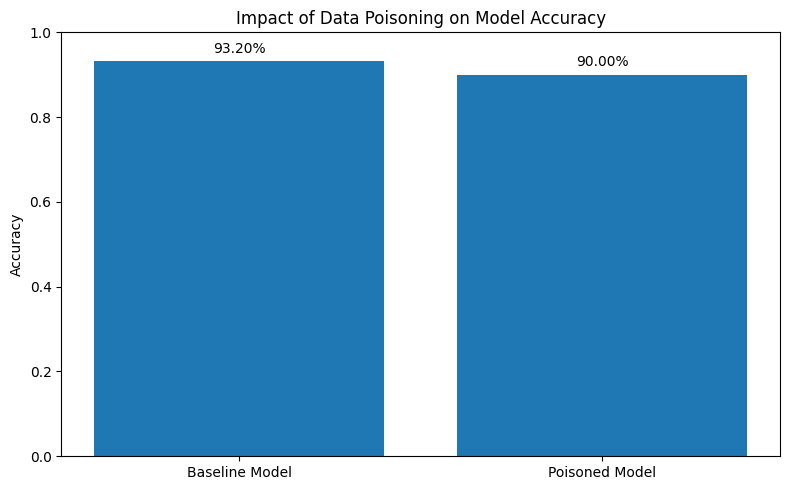

In [4]:
plt.figure(figsize=(8, 5))

plt.bar(comparison["Model"], comparison["Accuracy"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Impact of Data Poisoning on Model Accuracy")

for index, accuracy in enumerate(comparison["Accuracy"]):
    plt.text(index, accuracy + 0.02, f"{accuracy:.2%}", ha="center")

plt.tight_layout()
plt.show()

We can also compare the confusion matrices.

In [5]:
print("Baseline Confusion Matrix:")
print(confusion_matrix(y_test, baseline_predictions))

print("\nPoisoned Confusion Matrix:")
print(confusion_matrix(y_test, poisoned_predictions))

Baseline Confusion Matrix:
[[237  13]
 [ 21 229]]

Poisoned Confusion Matrix:
[[225  25]
 [ 25 225]]


Important: Random label flipping does not guarantee a dramatic accuracy reduction. Some models remain relatively robust to moderate random label noise. A small accuracy change is still a valid experimental result and illustrates why poisoning impact must be measured rather than assumed.

---

## 🛡️ Apply the Defence

One important defence against data poisoning is verifying the integrity of training labels.

In real-world applications, this may involve:

- Comparing incoming records against trusted datasets.
- Reviewing unexpected label changes.
- Validating data provenance.
- Restricting unauthorised modifications to training data.

For this controlled experiment, we'll assume that we have a trusted reference containing the original training labels.

We'll compare the poisoned labels against this reference to identify corrupted records.

This is an integrity-checking demonstration rather than a general-purpose method for detecting poisoning when trusted labels are unavailable.

In [6]:
trusted_labels = y_train.copy()

suspicious_indices = np.where(poisoned_labels != trusted_labels)[0]
detected_count = len(suspicious_indices)

print(f"Suspicious Labels Detected: {detected_count}")
print(f"Actual Poisoned Labels: {poison_count}")

cleaned_labels = poisoned_labels.copy()
cleaned_labels[suspicious_indices] = trusted_labels[suspicious_indices]

print(f"Labels Restored: {np.sum(cleaned_labels != poisoned_labels)}")

Suspicious Labels Detected: 450
Actual Poisoned Labels: 450
Labels Restored: 450


---

## 🧪 Verify the Defence

We'll now retrain the model using the corrected training labels.

After retraining, we'll evaluate the model against the same clean test dataset.

Finally, we'll compare all three models:

- Baseline Model — trained on clean data.
- Poisoned Model — trained on corrupted labels.
- Recovered Model — trained on corrected labels.

This allows us to verify whether restoring training data integrity also restores model performance.

In [7]:
recovered_model = LogisticRegression(max_iter=1000, random_state=42)
recovered_model.fit(X_train_scaled, cleaned_labels)

recovered_predictions = recovered_model.predict(X_test_scaled)
recovered_accuracy = accuracy_score(y_test, recovered_predictions)

results = pd.DataFrame({
    "Model": ["Baseline", "Poisoned", "Recovered"],
    "Accuracy": [baseline_accuracy, poisoned_accuracy, recovered_accuracy]
})

print(results.to_string(index=False))
print(f"\nRecovery Improvement: {recovered_accuracy - poisoned_accuracy:+.2%}")
print(f"Recovered Baseline Accuracy: {np.isclose(recovered_accuracy, baseline_accuracy)}")

    Model  Accuracy
 Baseline     0.932
 Poisoned     0.900
Recovered     0.932

Recovery Improvement: +3.20%
Recovered Baseline Accuracy: True


Let's visualise the final comparison.

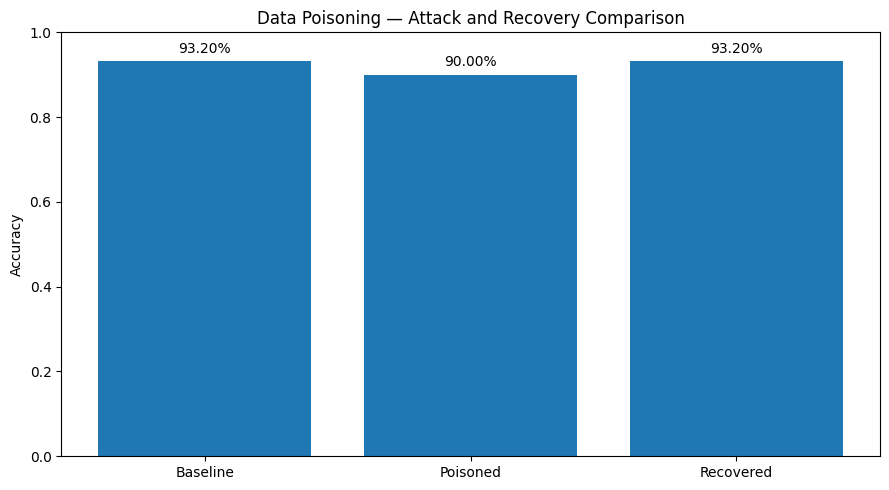

In [8]:
plt.figure(figsize=(9, 5))

plt.bar(results["Model"], results["Accuracy"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Data Poisoning — Attack and Recovery Comparison")

for index, accuracy in enumerate(results["Accuracy"]):
    plt.text(index, accuracy + 0.02, f"{accuracy:.2%}", ha="center")

plt.tight_layout()
plt.show()

---

## 📌 Security Takeaways

- Data poisoning manipulates the information used to train machine learning models.
- Label-flipping attacks deliberately introduce incorrect class labels into training datasets.
- Corrupted training data can affect classification accuracy and individual predictions.
- Comparing clean and poisoned models helps measure the impact of training data manipulation.
- Trusted reference datasets and data integrity checks can help identify unauthorised label changes.
- Restoring clean training data and retraining the model can recover its original performance.

---

## 🚀 Final Note

Machine learning models depend heavily on the quality and integrity of their training data.

Even when an ML algorithm is functioning correctly, corrupted training information can influence what the model learns and how it behaves.

By simulating data poisoning and verifying the effectiveness of integrity checks, we can better understand why protecting the training pipeline is an essential part of AI/ML security.

---